In [28]:
# Linear Regression Model - Experience vs Salary Prediction
# This demonstrates simple linear regression to predict salary based on years of experience
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm



In [ ]:
# Load the dataset
df = pd.read_csv('Experience_Salary.csv')

# Quick look at the data
print("First 5 rows:")
print(df.head())

print("\nDataset shape:", df.shape)

# Summary statistics - mean, std, min, max, quartiles
print("\nStatistical Summary:")
print(df.describe())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())


Skewness:
Experience_Years    0.083731
Salary_LPA          0.101051
dtype: float64
First 5 rows:
   Experience_Years  Salary_LPA
0               1.0         3.2
1               1.5         4.1
2               2.0         4.5
3               2.2         4.8
4               2.5         5.2

Dataset shape: (79, 2)

Statistical Summary:
       Experience_Years  Salary_LPA
count         79.000000   79.000000
mean           7.782278   13.094937
std            4.014805    5.974216
min            1.000000    3.200000
25%            4.400000    7.900000
50%            7.700000   12.800000
75%           11.100000   18.100000
max           15.000000   24.000000

Missing values:
Experience_Years    0
Salary_LPA          0
dtype: int64


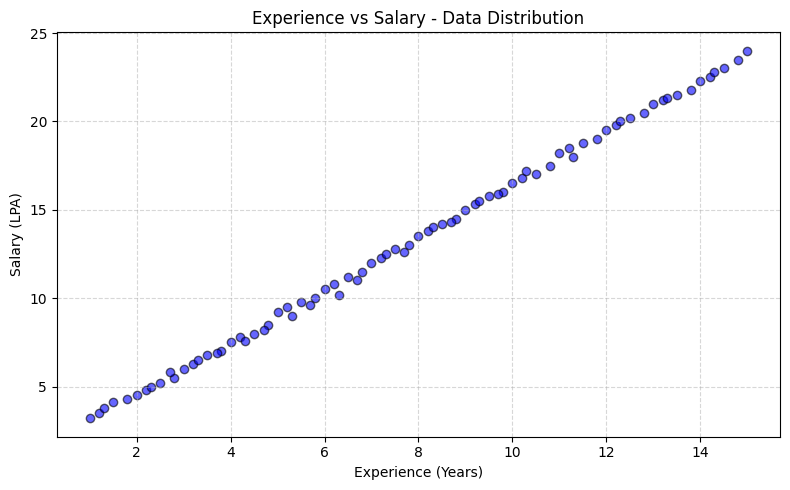

In [30]:
# Scatter plot to understand the relationship between Experience and Salary
# A linear pattern here means linear regression is a good fit
plt.figure(figsize=(8, 5))
plt.scatter(df['Experience_Years'], df['Salary_LPA'], color='blue', alpha=0.6, edgecolors='black')
plt.xlabel('Experience (Years)')
plt.ylabel('Salary (LPA)')
plt.title('Experience vs Salary - Data Distribution')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [43]:
# Define feature (X) and target (y)
# X = independent variable (Experience)
# y = dependent variable (Salary)
X = df[['Experience_Years']]
y = df['Salary_LPA']

# Split into 80% training and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

# Initialize and train the linear regression model
# The model learns the best-fit line: y = intercept + coefficient * X
model = LinearRegression()

# add_constant adds the intercept term (b) to the feature matrix
X_ols = sm.add_constant(df[['Experience_Years']])
y_ols = df['Salary_LPA']

# Fit OLS model and print summary
ols_model = sm.OLS(y_ols, X_ols).fit()
model.fit(X_train, y_train)

print("\nModel trained successfully!")
ols_model.summary()


Training samples: 63
Testing samples:  16

Model trained successfully!


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             Salary_LPA   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 6.979e+04
Date:                Thu, 02 Apr 2026   Prob (F-statistic):          1.21e-115
Time:                        17:06:42   Log-Likelihood:                 16.213
No. Observations:                  79   AIC:                            -28.43
Df Residuals:                      77   BIC:                            -23.69
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                1.5209      0.049     30.892      0.000       1.423       1.619
Experience_Years     1.4872      0.006    264.172      0.000       1.476       1.498
==============================================================================
Omnibus:                       11.367   Durbin-Watson:                   1.220
Prob(Omnibus):                  0.003   Jarque-Bera (JB):               11.945
Skew:                          -0.790   Prob(JB):                      0.00255
Kurtosis:                       4.065   Cond. No.                         19.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [32]:
# Model parameters define the equation of the best-fit line
# Intercept (b) = base salary when experience is 0
# Coefficient (m) = salary increase per additional year of experience
print(f"Intercept (b):   {model.intercept_:.4f}")
print(f"Coefficient (m): {model.coef_[0]:.4f}")
print(f"\nModel Equation: Salary = {model.intercept_:.4f} + {model.coef_[0]:.4f} × Experience")


Intercept (b):   1.5021
Coefficient (m): 1.4884

Model Equation: Salary = 1.5021 + 1.4884 × Experience


In [33]:
# Generate predictions on the test set
y_pred = model.predict(X_test)

# Evaluation Metrics:
# R² Score  - How well the model explains variance (1.0 = perfect, 0 = no predictive power)
# MAE       - Average absolute error in predictions (in LPA)
# RMSE      - Root mean squared error, penalizes larger errors more than MAE
print("Model Evaluation on Test Set:")
print(f"  R² Score : {r2_score(y_test, y_pred):.4f}")
print(f"  MAE      : {mean_absolute_error(y_test, y_pred):.4f} LPA")
print(f"  RMSE     : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f} LPA")


Model Evaluation on Test Set:
  R² Score : 0.9994
  MAE      : 0.1513 LPA
  RMSE     : 0.1793 LPA


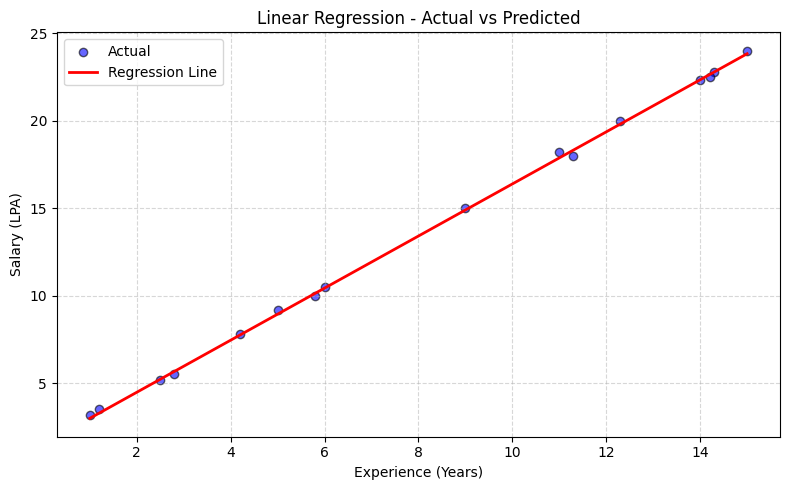

In [34]:
# Plot actual data points vs the predicted regression line
# Blue dots = actual test data, Red line = model's predictions
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color='blue', label='Actual', alpha=0.6, edgecolors='black')
plt.plot(X_test.sort_values('Experience_Years'), 
         model.predict(X_test.sort_values('Experience_Years')), 
         color='red', linewidth=2, label='Regression Line')
plt.xlabel('Experience (Years)')
plt.ylabel('Salary (LPA)')
plt.title('Linear Regression - Actual vs Predicted')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
# Predict salary for new experience values
# This is how the model can be used in production
test_experiences = [2, 5, 8, 12, 15]

print("Salary Predictions:")
print("-" * 35)
for exp in test_experiences:
    salary = model.predict(np.array([[exp]]))[0]
    print(f"  {exp:>2} years experience → ₹{salary:.2f} LPA")

# ols_model.summary()


Salary Predictions:
-----------------------------------
   2 years experience → ₹4.48 LPA
   5 years experience → ₹8.94 LPA
   8 years experience → ₹13.41 LPA
  12 years experience → ₹19.36 LPA
  15 years experience → ₹23.83 LPA


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-p

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             Salary_LPA   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 6.979e+04
Date:                Thu, 02 Apr 2026   Prob (F-statistic):          1.21e-115
Time:                        14:57:46   Log-Likelihood:                 16.213
No. Observations:                  79   AIC:                            -28.43
Df Residuals:                      77   BIC:                            -23.69
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                1.5209      0.049     30.892      0.000       1.423       1.619
Experience_Years     1.4872      0.006    264.172      0.000       1.476       1.498
==============================================================================
Omnibus:                       11.367   Durbin-Watson:                   1.220
Prob(Omnibus):                  0.003   Jarque-Bera (JB):               11.945
Skew:                          -0.790   Prob(JB):                      0.00255
Kurtosis:                       4.065   Cond. No.                         19.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

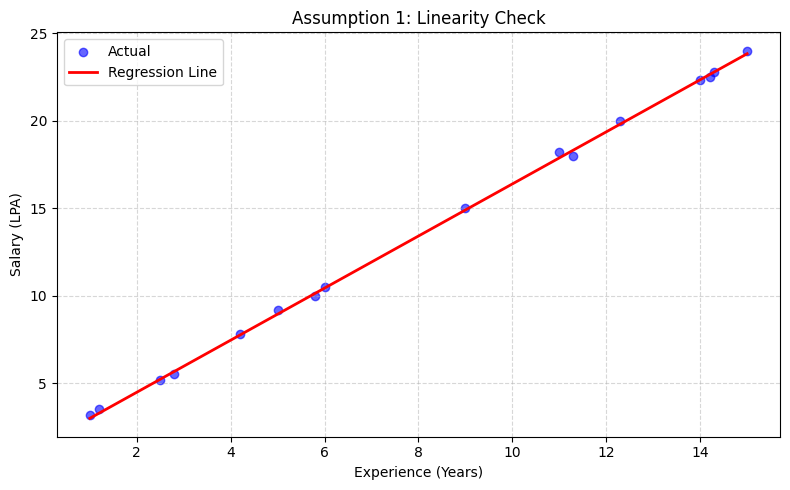

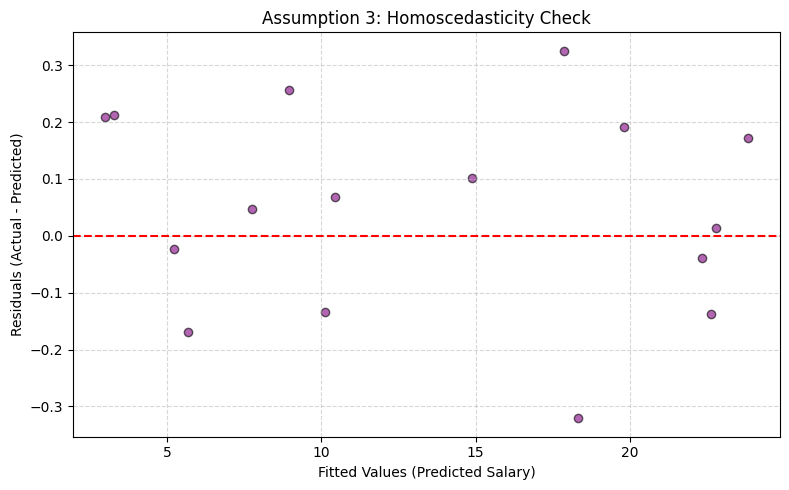

Text(0, 0.5, 'Frequency')

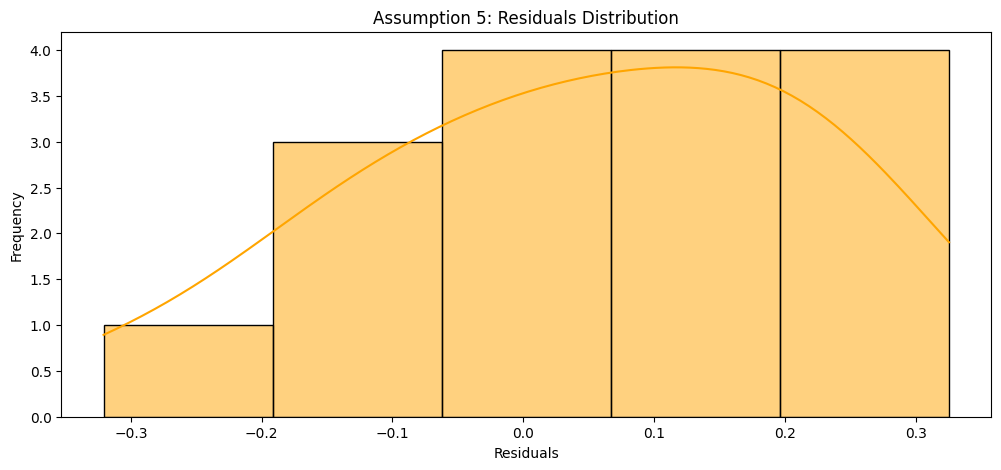

In [44]:
from scipy import stats
import seaborn as sns

# Get predictions and residuals
y_pred = model.predict(X_test)
residuals = y_test - y_pred



# ASSUMPTION 1: Linearity
# The relationship between X and y should be linear
# Check: Scatter plot should show a linear pattern

plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color='blue', alpha=0.6, label='Actual')
plt.plot(X_test.sort_values('Experience_Years'),
         model.predict(X_test.sort_values('Experience_Years')),
         color='red', linewidth=2, label='Regression Line')
plt.xlabel('Experience (Years)')
plt.ylabel('Salary (LPA)')
plt.title('Assumption 1: Linearity Check')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Assumption 2: No Multicollinearity
# Not applicable here since we have only one feature (Experience)

# Assumption 3: Homoscedasticity
# The variance of residuals should be constant across all levels of X
# Check: Residuals vs Fitted plot should show random scatter (no funnel shape)

# Assumption 4: No Autocorrelation
# Residuals should not be correlated with each other
# Check: Residuals vs Fitted plot should show no patterns (random scatter)
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, color='purple', alpha=0.6, edgecolors='black')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Fitted Values (Predicted Salary)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Assumption 3: Homoscedasticity Check')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


# Assumption 5: Normal Residuals
# Residuals should be approximately normally distributed
# Check: Histogram  should show normal distribution

plt.figure(figsize=(12, 5))
sns.histplot(residuals, kde=True, color='orange', edgecolor='black')
plt.title('Assumption 5: Residuals Distribution')
plt.xlabel('Residuals')
plt.ylabel('Frequency')






